In [1]:
%reload_ext watermark
%watermark -v -p pandas,numpy,geopandas,libpysal,esda,spreg,contextily,splot,scipy,matplotlib

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.10.0

pandas    : 3.0.1
numpy     : 2.3.5
geopandas : 1.1.2
libpysal  : 4.14.1
esda      : 2.8.1
spreg     : 1.8.5
contextily: 1.7.0
splot     : 1.1.7
scipy     : 1.17.0
matplotlib: 3.10.8



# Graph-Based Spatial-Temporal Urban Mobility Analytics of London's Santander Cycles

 GitHub Repository: [https://github.com/Tiara-cg/Changge-Zhang-Glasgow-Advanced-Topics-for-Urban-Analytics-.git]

## Abstract

 This project investigates London's Santander Cycles system using a spatial-temporal urban analytics workflow integrating graph modelling, spatial analysis, and machine learning. Journey records from January to May 2025 were used to construct an origin-destination mobility network, where stations are represented as nodes and trip flows as weighted edges.

 The analysis identifies temporal mobility patterns, influential cycling hubs, spatial mobility communities, and distance decay effects. Graph-derived and spatial features are further used to predict station-level trip intensity. The results show that London's bike-sharing system is spatially uneven, highly networked, and structured around distinct mobility regions. These findings provide evidence for cycling infrastructure planning, station redistribution, and sustainable urban mobility policy.

## 1. Introduction

 Bike-sharing systems are increasingly important for sustainable urban mobility. In large cities such as London, shared cycling can reduce congestion, improve local accessibility, and support low-carbon transport transitions.

 Urban mobility is inherently spatial and relational. Bike-sharing journeys connect different stations and neighbourhoods through repeated flows, creating a spatial mobility network. Therefore, analysing bike-sharing only as a demand prediction problem is insufficient. A more advanced urban analytics approach should examine spatial structure, network centrality, mobility communities, and the relationship between urban space and travel behaviour.

 This project develops a spatial-temporal urban analytics workflow for London's Santander Cycles system. It integrates data wrangling, graph modelling, spatial clustering, spatial interaction analysis, and machine learning to understand how bike-sharing mobility is structured across London.

## 2. Research Questions

 This project addresses four research questions related to London's Santander Cycles system:

 1. How are bike-sharing journeys spatially and temporally distributed across London?

 2. Which stations function as important mobility hubs within the urban bike-sharing network?

 3. Can graph-based community detection and spatial clustering reveal functional urban mobility regions?

 4. To what extent can spatial and graph-derived features improve prediction of station-level trip intensity?

## 3. Data and Sources

 This project uses journey-level bike-sharing data obtained from the Transport for London (TfL) Santander Cycles open data service. The dataset contains all recorded bike-sharing journeys between January and May 2025.

 The combined dataset contains approximately 3.5 million journey records and includes information on journey start time, end time, origin station, destination station, bike model, and trip duration.

 To support spatial analysis, station coordinate data were obtained from the TfL BikePoint API and integrated with the journey dataset. These coordinates enabled spatial mapping, network analysis, community detection, and distance-based spatial interaction analysis.

 The large-scale and spatially explicit nature of the dataset makes it suitable for advanced urban analytics workflows integrating graph modelling, spatial analysis, and machine learning.

## 4. Methodology

 This project develops a spatial-temporal urban analytics workflow integrating graph modelling, spatial clustering, spatial interaction analysis, and machine learning.

 The analytical workflow consists of five main stages:

 1. Data cleaning and temporal feature engineering;

 2. Construction of a directed weighted origin-destination mobility network;

 3. Graph-based urban mobility analysis, including centrality analysis and community detection;

 4. Spatial analysis, including spatial clustering and distance decay analysis;

 5. Machine learning prediction of station-level trip intensity using spatial and graph-derived features.

 This integrated workflow enables both spatial interpretation of urban mobility structure and AI-enhanced predictive analysis.

In [2]:
import pandas as pd
import numpy as np
import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
import folium

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
files = glob.glob("*.csv")

print("Number of files found:", len(files))
print(files)

df_list = []

for file in files:
    temp = pd.read_csv(file)
    temp["source_file"] = file
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()

Number of files found: 10
['411JourneyDataExtract01Jan2025-14Jan2025.csv', '412JourneyDataExtract15Jan2025-31Jan2025.csv', '413JourneyDataExtract01Feb2025-14Feb2025.csv', '414JourneyDataExtract15Feb2025-28Feb2025.csv', '415JourneyDataExtract01Mar2025-14Mar2025.csv', '416JourneyDataExtract15Mar2025-31Mar2025.csv', '417JourneyDataExtract01Apr2025-14Apr2025.csv', '418JourneyDataExtract15Apr2025-30Apr2025.csv', '419JourneyDataExtract01May2025-14May2025.csv', '420JourneyDataExtract14May2025-31May2025.csv']
(3538463, 12)


,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms),source_file
0,145666816,2025-01-14 23:59,1043,"Museum of London, Barbican",2025-01-15 00:13,200149,"Watney Street, Shadwell",55223,CLASSIC,14m 30s,870468,411JourneyDataExtract01Jan2025-14Jan2025.csv
1,145666817,2025-01-14 23:59,300015,"Binfield Road, Stockwell",2025-01-15 00:04,300229,"Sidney Road, Stockwell",20325,CLASSIC,5m 7s,307181,411JourneyDataExtract01Jan2025-14Jan2025.csv
2,145666818,2025-01-14 23:59,1068,"Norton Folgate, Liverpool Street",2025-01-15 00:10,1051,"Shoreditch Park, Hoxton",50432,CLASSIC,10m 40s,640755,411JourneyDataExtract01Jan2025-14Jan2025.csv
3,145666819,2025-01-14 23:59,1159,"Berry Street, Clerkenwell",2025-01-15 00:10,1007,"Drury Lane, Covent Garden",56794,CLASSIC,10m 42s,642548,411JourneyDataExtract01Jan2025-14Jan2025.csv
4,145666812,2025-01-14 23:58,200048,"Page Street, Westminster",2025-01-15 00:14,1058,"Edgware Road Station, Marylebone",63546,PBSC_EBIKE,15m 44s,944185,411JourneyDataExtract01Jan2025-14Jan2025.csv


In [4]:
df.columns

Index(['Number', 'Start date', 'Start station number', 'Start station',
       'End date', 'End station number', 'End station', 'Bike number',
       'Bike model', 'Total duration', 'Total duration (ms)', 'source_file'],
      dtype='str')

## 5. Data Cleaning and Feature Engineering

 Journey start and end times were converted into datetime format to support temporal analysis and feature extraction. Trip duration was transformed from milliseconds into minutes for interpretability.

 To improve data quality, extremely short journeys and unusually long journeys were removed to reduce the influence of likely errors, accidental dockings, or atypical mobility behaviour.

 Additional temporal features were constructed, including hour of day, weekday, month, peak-hour indicators, and weekend indicators. These features support subsequent temporal and machine learning analyses.

In [5]:
df["Start date"] = pd.to_datetime(df["Start date"])
df["End date"] = pd.to_datetime(df["End date"])

df["duration_min"] = df["Total duration (ms)"] / 60000

df = df[(df["duration_min"] >= 1) & (df["duration_min"] <= 120)]

df["hour"] = df["Start date"].dt.hour
df["dayofweek"] = df["Start date"].dt.dayofweek
df["weekday_name"] = df["Start date"].dt.day_name()
df["month"] = df["Start date"].dt.month
df["date"] = df["Start date"].dt.date

df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["is_peak"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

df.shape

(3492383, 20)

## 6. Spatial-Temporal Mobility Analysis

 This section investigates temporal mobility patterns within London's bike-sharing system. Hourly, weekly, and monthly variations were analysed to understand how cycling activity changes over time.

 Temporal mobility analysis helps identify commuting behaviour, peak travel periods, and broader urban mobility rhythms across the city.

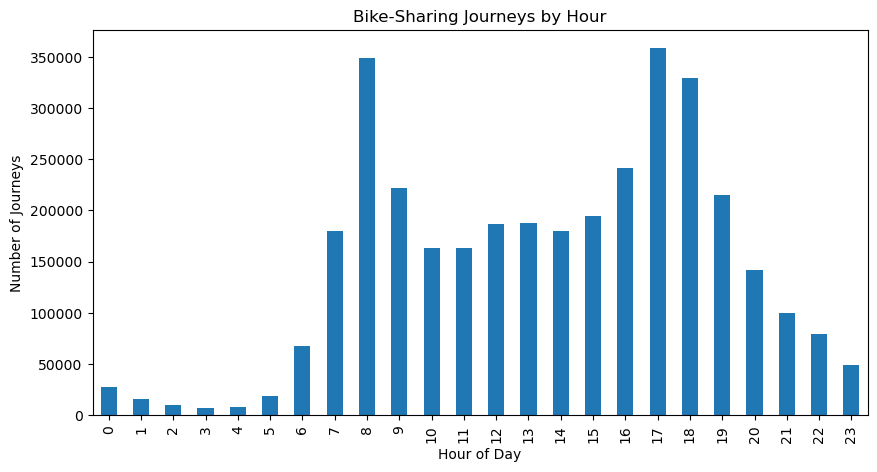

In [6]:
hourly_counts = df.groupby("hour").size()

plt.figure(figsize=(10,5))
hourly_counts.plot(kind="bar")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Journeys")
plt.title("Bike-Sharing Journeys by Hour")
plt.show()

 The hourly distribution reveals strong morning and evening commuting peaks, suggesting that Santander Cycles are closely integrated into London's daily commuting system.

 Lower activity during late-night periods reflects reduced urban mobility demand outside standard travel hours.

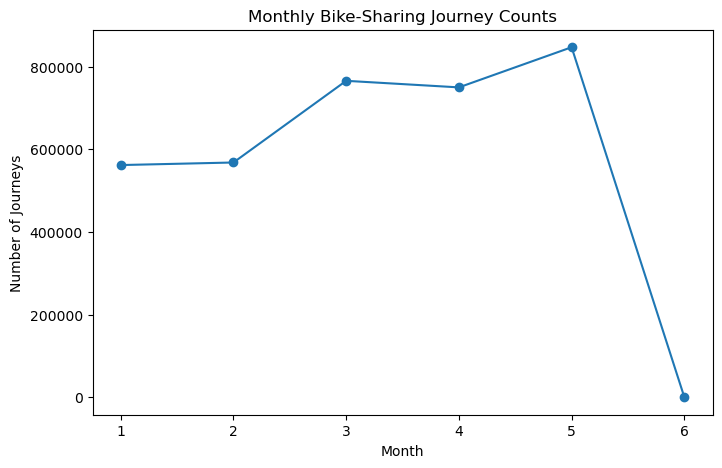

In [7]:
monthly_counts = df.groupby("month").size()

plt.figure(figsize=(8,5))
monthly_counts.plot(kind="line", marker="o")
plt.xlabel("Month")
plt.ylabel("Number of Journeys")
plt.title("Monthly Bike-Sharing Journey Counts")
plt.show()

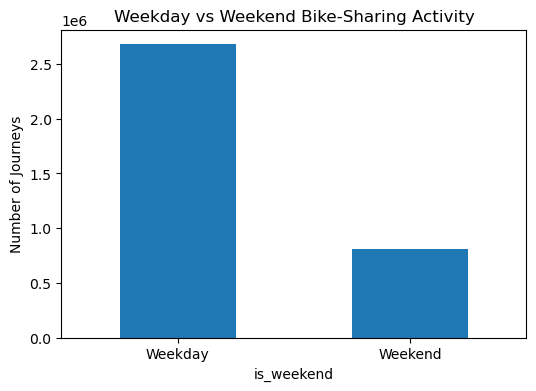

In [8]:
weekend_counts = df.groupby("is_weekend").size()

plt.figure(figsize=(6,4))
weekend_counts.plot(kind="bar")
plt.xticks([0,1], ["Weekday", "Weekend"], rotation=0)
plt.ylabel("Number of Journeys")
plt.title("Weekday vs Weekend Bike-Sharing Activity")
plt.show()

 Differences between weekday and weekend activity suggest that bike-sharing serves both utilitarian and recreational mobility functions. Weekday patterns are more strongly associated with commuting behaviour, while weekend activity is comparatively more evenly distributed across the day.

## 7. Origin-Destination Flow Construction

 To represent bike-sharing as an urban mobility network, individual trips were aggregated into origin-destination flows. Each OD pair records the number of journeys between two stations.

In [9]:
od_flows = (
    df.groupby(["Start station", "End station"])
      .size()
      .reset_index(name="flow_count")
)

# Remove self-loops
od_flows = od_flows[od_flows["Start station"] != od_flows["End station"]]

od_flows = od_flows.sort_values("flow_count", ascending=False)

od_flows.head(20)

,Start station,End station,flow_count
2467,"Ackroyd Drive, Bow","Maplin Street, Mile End",1419
190510,"Maplin Street, Mile End","Ackroyd Drive, Bow",1287
159162,"Hyde Park Corner, Hyde Park","Albert Gate, Hyde Park",1150
277306,"Southwick Street, Paddington","Exhibition Road, Knightsbridge",1138
5772,"Albert Gate, Hyde Park","Hyde Park Corner, Hyde Park",1086
195506,"Monier Road, Hackney Wick","Stratford Station, Stratford",1008
159217,"Hyde Park Corner, Hyde Park","Black Lion Gate, Kensington Gardens",1005
33039,"Black Lion Gate, Kensington Gardens","Hyde Park Corner, Hyde Park",977
159756,"Hyde Park Corner, Hyde Park","Triangle Car Park, Hyde Park",959
292547,"Stratford Station, Stratford","Monier Road, Hackney Wick",958


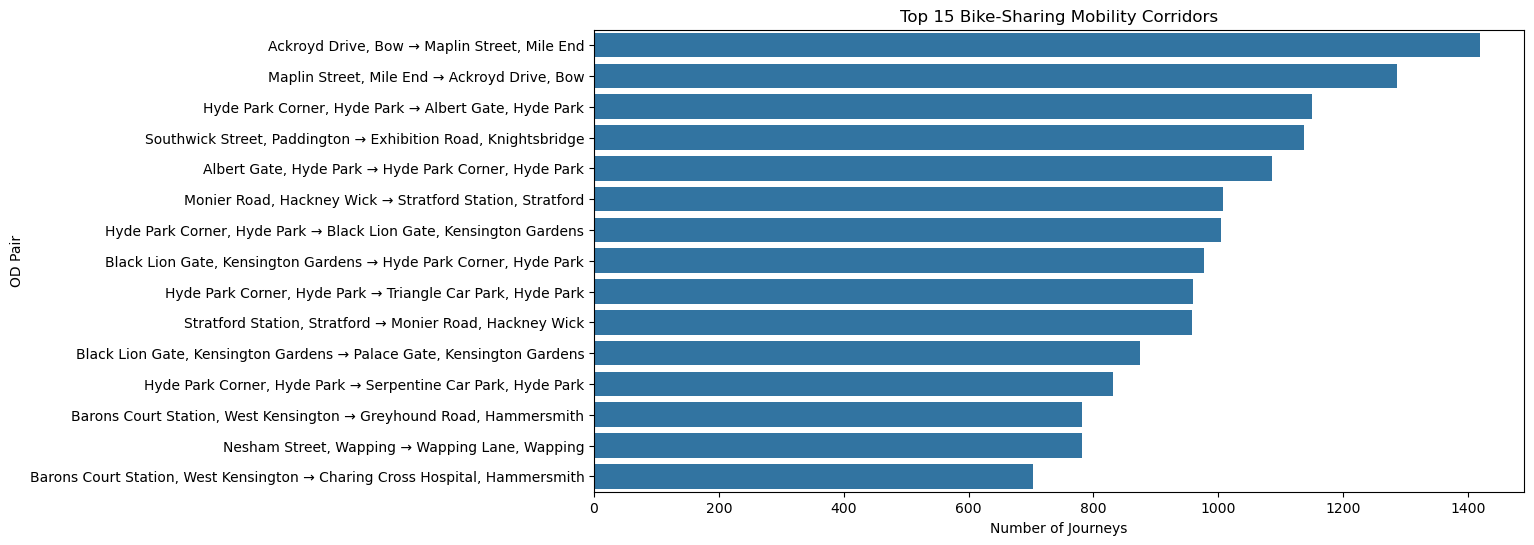

In [10]:
top_flows = od_flows.head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_flows,
    x="flow_count",
    y=top_flows["Start station"] + " → " + top_flows["End station"]
)
plt.xlabel("Number of Journeys")
plt.ylabel("OD Pair")
plt.title("Top 15 Bike-Sharing Mobility Corridors")
plt.show()

## 8. Graph-Based Urban Mobility Network Analysis

 To represent London's bike-sharing system as an urban mobility network, individual journeys were aggregated into origin-destination flows.

 Stations were represented as nodes, while trip flows between stations were represented as weighted directed edges. Edge weights correspond to the number of observed journeys and therefore capture the intensity of mobility interactions across the city.

 Graph modelling enables investigation of urban mobility structure beyond simple trip counts by examining network connectivity, station importance, and spatial organisation.

In [11]:
G = nx.from_pandas_edgelist(
    od_flows,
    source="Start station",
    target="End station",
    edge_attr="flow_count",
    create_using=nx.DiGraph()
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 812
Number of edges: 342942


## 8.1 Network Centrality Analysis

 Network centrality measures were used to identify influential stations within London's bike-sharing system.

 Degree centrality measures how strongly connected a station is within the network. Betweenness centrality identifies stations that function as bridges linking different parts of the network. PageRank centrality highlights stations connected to other highly influential stations and therefore captures broader network importance.

 Together, these measures provide insight into urban accessibility, mobility concentration, and transport network structure.

In [12]:
degree_centrality = nx.degree_centrality(G)

betweenness_centrality = nx.betweenness_centrality(
    G,
    weight="flow_count",
    normalized=True
)

pagerank = nx.pagerank(
    G,
    weight="flow_count"
)

centrality_df = pd.DataFrame({
    "station": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values()),
    "betweenness_centrality": [betweenness_centrality[s] for s in degree_centrality.keys()],
    "pagerank": [pagerank[s] for s in degree_centrality.keys()]
})

centrality_df.sort_values("pagerank", ascending=False).head(15)

,station,degree_centrality,betweenness_centrality,pagerank
24,"Waterloo Station 3, Waterloo",1.342787,0.001119,0.005516
85,"Waterloo Station 1, Waterloo",1.721332,0.000804,0.004987
167,"Hop Exchange, The Borough",1.744760,0.000670,0.004404
66,"Wormwood Street, Liverpool Street",1.732429,0.000685,0.004251
5,"Exhibition Road, Knightsbridge",1.595561,0.000553,0.004167
75,"Brushfield Street, Liverpool Street",1.606658,0.000791,0.004053
233,"St. James's Square, St. James's",1.754624,0.000379,0.003915
153,"Argyle Street, Kings Cross",1.705302,0.000754,0.003731
2,"Hyde Park Corner, Hyde Park",1.638718,0.000916,0.003677
103,"Queen Street 2, Bank",1.763255,0.000571,0.003620


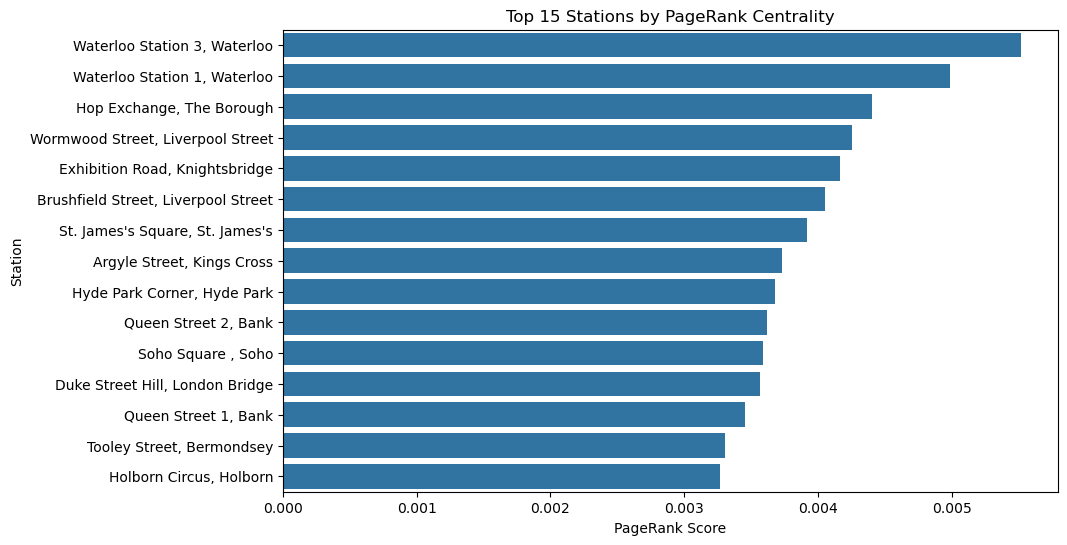

In [13]:
top_pr = centrality_df.sort_values("pagerank", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_pr,
    x="pagerank",
    y="station"
)
plt.title("Top 15 Stations by PageRank Centrality")
plt.xlabel("PageRank Score")
plt.ylabel("Station")
plt.show()

 Stations with high PageRank centrality are spatially concentrated around central London and major transport interchanges, including Waterloo, Bank, and Liverpool Street.

 This suggests that bike-sharing importance is strongly associated with broader patterns of urban accessibility and transport connectivity.

## 9. Community Detection and Spatial Structure

 Community detection was applied to identify groups of stations that are more densely connected internally than externally.

 In urban mobility systems, these communities may represent functional mobility regions such as commuting corridors, commercial centres, transport interchange zones, or leisure-oriented cycling areas.

 Understanding these communities provides insight into how London's urban structure shapes cycling mobility behaviour.

In [14]:
from networkx.algorithms.community import greedy_modularity_communities

G_undirected = G.to_undirected()

communities = greedy_modularity_communities(
    G_undirected,
    weight="flow_count"
)

print("Number of communities:", len(communities))

community_map = {}

for i, community in enumerate(communities):
    for station in community:
        community_map[station] = i

centrality_df["community"] = centrality_df["station"].map(community_map)

centrality_df["community"].value_counts()

Number of communities: 4


community
0    354
1    329
2    104
3     25
Name: count, dtype: int64

## 10. Spatial Integration with TfL BikePoint Coordinates

 Station coordinate data from TfL BikePoint were used to spatially locate stations. This enables mapping of centrality and community structure across London.

In [15]:
stations = pd.read_json("bike_stations.json")

stations = stations[["commonName", "lat", "lon"]]

stations.columns = ["station", "latitude", "longitude"]

stations.head()

,station,latitude,longitude
0,"River Street , Clerkenwell",51.529163,-0.109970
1,"Phillimore Gardens, Kensington",51.499606,-0.197574
2,"Christopher Street, Liverpool Street",51.521283,-0.084605
3,"St. Chad's Street, King's Cross",51.530059,-0.120973
4,"Sedding Street, Sloane Square",51.493130,-0.156876


In [16]:
centrality_geo = centrality_df.merge(
    stations,
    on="station",
    how="left"
)

centrality_geo.isnull().sum()

station                    0
degree_centrality          0
betweenness_centrality     0
pagerank                   0
community                  0
latitude                  19
longitude                 19
dtype: int64

In [17]:
centrality_geo = centrality_geo.dropna(subset=["latitude", "longitude"])

In [18]:
m = folium.Map(location=[51.5074, -0.1278], zoom_start=11)

for _, row in centrality_geo.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=max(row["pagerank"] * 3000, 3),
        popup=row["station"],
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m

 The PageRank map shows that influential stations are spatially concentrated around central London and major transport corridors. This suggests that bike-sharing importance is not evenly distributed but structured around high-accessibility urban areas.

In [19]:
import matplotlib.cm as cm
import matplotlib.colors as colors

unique_communities = sorted(centrality_geo["community"].unique())
colormap = cm.get_cmap("tab10", len(unique_communities))

m2 = folium.Map(location=[51.5074, -0.1278], zoom_start=11)

for _, row in centrality_geo.iterrows():
    community_color = colors.rgb2hex(colormap(int(row["community"])))

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=community_color,
        fill=True,
        fill_color=community_color,
        fill_opacity=0.8,
        popup=f"{row['station']} | Community {row['community']}"
    ).add_to(m2)

m2

C:\Users\18095\AppData\Local\Temp\ipykernel_7760\4234098000.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("tab10", len(unique_communities))


 The community structure reveals clear spatial clustering across London. Communities broadly correspond to geographically coherent urban regions, suggesting that bike-sharing flows are shaped by underlying urban spatial structure rather than random movement patterns.

 The separation between eastern and western communities may reflect differences in land use, employment concentration, transport connectivity, and commuting behaviour.

In [20]:
!pip install libpysal esda

## 11. Spatial Autocorrelation Analysis

 To further investigate the spatial structure of London's bike-sharing system, Moran’s I spatial autocorrelation analysis was applied to station PageRank scores.

 Moran’s I measures whether high or low values are spatially clustered rather than randomly distributed across geographic space. In the context of urban mobility, significant positive spatial autocorrelation would indicate that influential bike-sharing stations tend to cluster geographically.

In [21]:
from libpysal.weights import KNN
from esda.moran import Moran

moran_df = centrality_geo.dropna(subset=[
    "latitude",
    "longitude",
    "pagerank"
]).copy()

coords = moran_df[["longitude", "latitude"]].values

w = KNN.from_array(coords, k=8)

w.transform = "R"

moran = Moran(
    moran_df["pagerank"],
    w
)

print("Moran's I:", moran.I)
print("P-value:", moran.p_sim)

Moran's I: 0.20141907483294955
P-value: 0.001


The Moran’s I result indicates positive spatial autocorrelation in PageRank centrality, suggesting that influential bike-sharing hubs are spatially concentrated rather than randomly distributed. This means that high-influence stations tend to be located near other influential stations, reflecting the spatial organisation of London’s bike-sharing network around key urban mobility hubs.

### 11.1 Spatial Autocorrelation of Station-Level Trip Intensity

In addition to testing the spatial autocorrelation of PageRank centrality, this section examines whether station-level trip intensity is spatially clustered. This provides a more direct test of whether high-demand bike-sharing stations are geographically concentrated across London.

In [35]:
trip_counts = (
    df.groupby("Start station")
      .size()
      .reset_index(name="trip_count")
)

moran_demand_df = centrality_geo.merge(
    trip_counts,
    left_on="station",
    right_on="Start station",
    how="left"
)

moran_demand_df = moran_demand_df.dropna(
    subset=["latitude", "longitude", "trip_count"]
).copy()

coords_demand = moran_demand_df[["longitude", "latitude"]].values

w_demand = KNN.from_array(coords_demand, k=8)
w_demand.transform = "R"

moran_trip = Moran(
    moran_demand_df["trip_count"],
    w_demand
)

print("Moran's I for trip intensity:", moran_trip.I)
print("P-value:", moran_trip.p_sim)

Moran's I for trip intensity: 0.19440232061995918
P-value: 0.001


In [36]:
from esda.moran import Moran_Local

lisa_trip = Moran_Local(
    moran_demand_df["trip_count"],
    w_demand
)

moran_demand_df["lisa_q"] = lisa_trip.q
moran_demand_df["lisa_p"] = lisa_trip.p_sim

def classify_lisa(row):
    if row["lisa_p"] >= 0.05:
        return "Not significant"
    elif row["lisa_q"] == 1:
        return "High-High"
    elif row["lisa_q"] == 2:
        return "Low-High"
    elif row["lisa_q"] == 3:
        return "Low-Low"
    elif row["lisa_q"] == 4:
        return "High-Low"

moran_demand_df["lisa_cluster"] = moran_demand_df.apply(classify_lisa, axis=1)

moran_demand_df["lisa_cluster"].value_counts()

lisa_cluster
Not significant    599
Low-Low            101
High-High           45
Low-High            30
High-Low            18
Name: count, dtype: int64

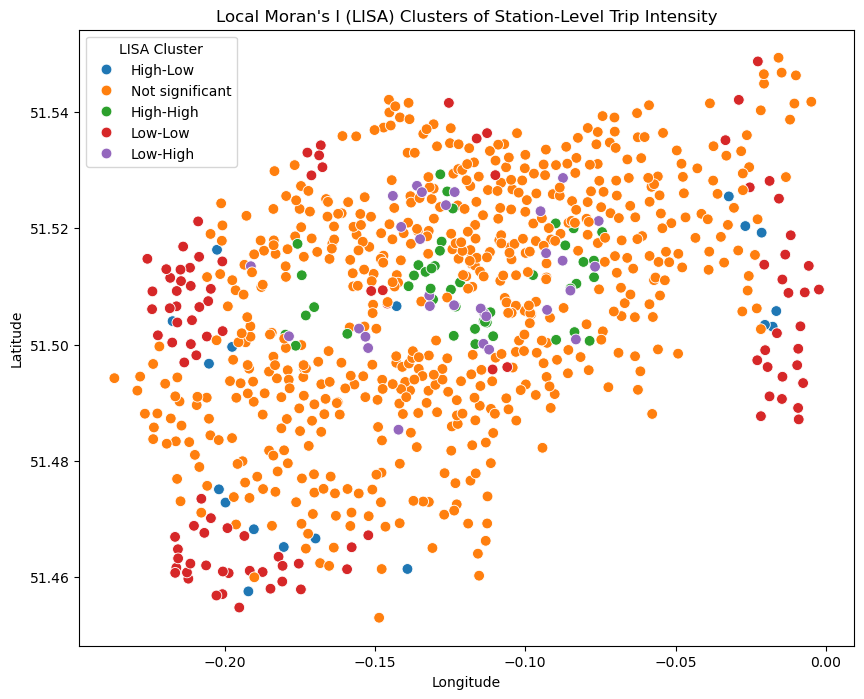

In [37]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=moran_demand_df,
    x="longitude",
    y="latitude",
    hue="lisa_cluster",
    s=60
)

plt.title("Local Moran's I (LISA) Clusters of Station-Level Trip Intensity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="LISA Cluster")
plt.show()

The additional Moran’s I result for station-level trip intensity confirms that bike-sharing demand itself is also spatially clustered. The LISA results further identify local clusters of demand, including High-High stations where high-demand stations are surrounded by other high-demand stations, and Low-Low stations where weaker demand is spatially grouped. Together, these results show that both network influence and trip intensity are geographically organised rather than randomly distributed.

## 12. Spatial Clustering and Hotspot Analysis

 DBSCAN clustering was applied to station coordinates to identify spatial concentrations of bike-sharing infrastructure across London.

 Unlike graph-based community detection, which identifies mobility interaction structure, DBSCAN identifies geographically concentrated station clusters and potential spatial hotspots.

In [22]:
trip_counts = (
    df.groupby("Start station")
      .size()
      .reset_index(name="trip_count")
)

station_ml = centrality_geo.merge(
    trip_counts,
    left_on="station",
    right_on="Start station",
    how="left"
)

station_ml = station_ml.drop(columns=["Start station"])
station_ml = station_ml.dropna(subset=["trip_count", "latitude", "longitude"])

station_ml.head()

,station,degree_centrality,betweenness_centrality,pagerank,community,latitude,longitude,trip_count
0,"Ackroyd Drive, Bow",0.755857,0.000632,0.001318,1,51.520398,-0.026768,5237
1,"Maplin Street, Mile End",0.821208,0.000860,0.001998,1,51.525501,-0.032267,7587
2,"Hyde Park Corner, Hyde Park",1.638718,0.000916,0.003677,0,51.503117,-0.153520,22499
3,"Albert Gate, Hyde Park",1.479655,0.000854,0.002802,0,51.502953,-0.158456,13871
4,"Southwick Street, Paddington",1.133169,0.001354,0.001305,0,51.515953,-0.169249,5470


In [23]:
coords = station_ml[["longitude", "latitude"]].values
coords_scaled = StandardScaler().fit_transform(coords)

dbscan = DBSCAN(eps=0.15, min_samples=5)
station_ml["spatial_cluster"] = dbscan.fit_predict(coords_scaled)

station_ml["spatial_cluster"].value_counts()

spatial_cluster
 1     540
-1     132
 5      17
 2      12
 3      12
 6      10
 12      8
 0       7
 15      7
 10      6
 4       6
 7       6
 8       6
 13      6
 11      5
 16      5
 14      4
 9       4
Name: count, dtype: int64

 The DBSCAN results indicate that bike-sharing stations are strongly concentrated within highly accessible central London areas, while peripheral areas exhibit lower station density and weaker network integration.

 These spatial inequalities may reflect broader differences in transport accessibility, urban density, and cycling infrastructure provision across London.

## 13. Spatial Interaction and Distance Decay

 Spatial interaction analysis was conducted by calculating geodesic distances between origin and destination stations.

 Distance decay theory suggests that mobility interactions generally decrease as spatial distance increases. Analysing trip distances therefore provides insight into how urban spatial structure constrains cycling behaviour across London.

In [24]:
start_coords = stations.rename(columns={
    "station": "Start station",
    "latitude": "start_lat",
    "longitude": "start_lon"
})

end_coords = stations.rename(columns={
    "station": "End station",
    "latitude": "end_lat",
    "longitude": "end_lon"
})

df_geo = df.merge(start_coords, on="Start station", how="left")
df_geo = df_geo.merge(end_coords, on="End station", how="left")

df_geo = df_geo.dropna(subset=["start_lat", "start_lon", "end_lat", "end_lon"])

In [25]:
from geopy.distance import geodesic

df_geo["trip_distance_km"] = df_geo.apply(
    lambda row: geodesic(
        (row["start_lat"], row["start_lon"]),
        (row["end_lat"], row["end_lon"])
    ).km,
    axis=1
)

df_geo["trip_distance_km"].describe()

count    3.389456e+06
mean     2.404414e+00
std      1.723926e+00
min      0.000000e+00
25%      1.149512e+00
50%      2.005223e+00
75%      3.229934e+00
max      1.638829e+01
Name: trip_distance_km, dtype: float64

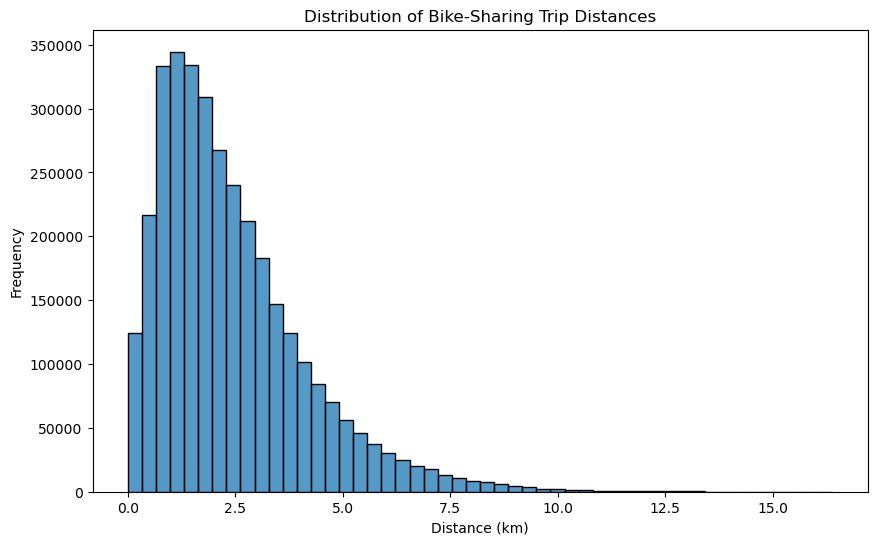

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(df_geo["trip_distance_km"], bins=50)
plt.title("Distribution of Bike-Sharing Trip Distances")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

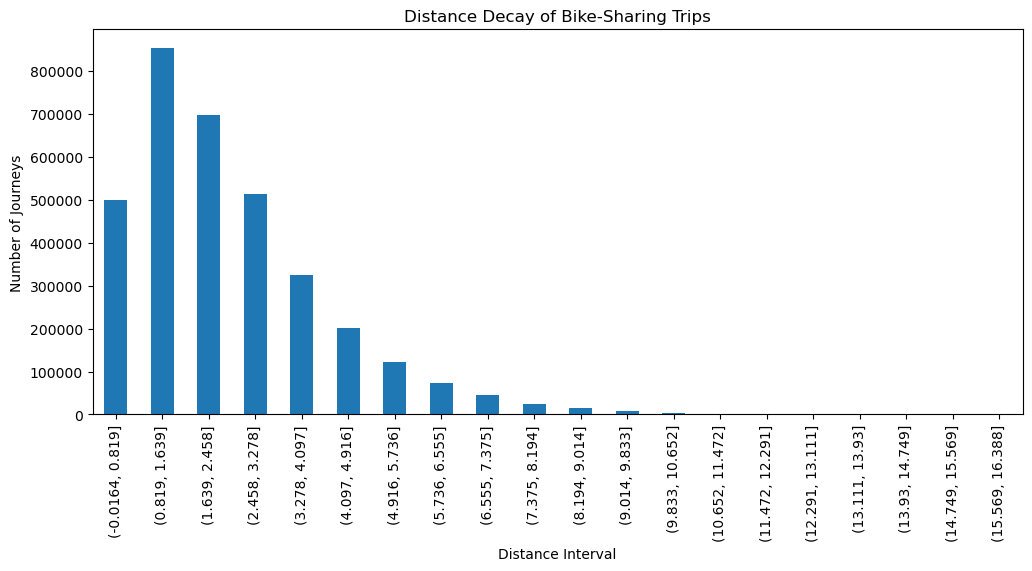

In [27]:
distance_flow = (
    df_geo.groupby(pd.cut(df_geo["trip_distance_km"], bins=20))
    .size()
)

distance_flow.plot(kind="bar", figsize=(12,5))
plt.title("Distance Decay of Bike-Sharing Trips")
plt.xlabel("Distance Interval")
plt.ylabel("Number of Journeys")
plt.show()

 The results show a clear distance decay effect, with most bike-sharing journeys occurring over relatively short distances.

 This supports the role of bike-sharing as a first-mile, last-mile, and short-distance urban transport mode integrated into the wider public transport system.

## 14. Machine Learning: Station-Level Trip Intensity Prediction

 Machine learning was used to predict station-level trip intensity using spatial and graph-derived features.

 The target variable represents the number of journeys originating from each station. Predictor variables include spatial coordinates, network centrality measures, community membership, and spatial clustering indicators.

 A Random Forest Regression model was used because it can capture nonlinear relationships and complex interactions between urban spatial variables.

In [28]:
model_df = station_ml[[
    "trip_count",
    "latitude",
    "longitude",
    "degree_centrality",
    "betweenness_centrality",
    "pagerank",
    "community",
    "spatial_cluster"
]].dropna()

model_df = pd.get_dummies(
    model_df,
    columns=["community", "spatial_cluster"],
    drop_first=True
)

X = model_df.drop(columns=["trip_count"])
y = model_df["trip_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [30]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [31]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, rf_pred) ** 0.5
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,334.980232,835.174443,0.889518
1,Random Forest,338.097547,918.849208,0.866271


### 14.1 Robustness Check: Random Forest without PageRank

Because PageRank is derived from the observed mobility network, it may be closely related to station-level trip intensity. To test whether the model remains informative without this dominant network-derived predictor, a robustness check was conducted by removing PageRank from the feature set.

In [38]:
X_no_pagerank = X.drop(columns=["pagerank"], errors="ignore")

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pagerank,
    y,
    test_size=0.2,
    random_state=42
)

rf_np = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_np.fit(X_train_np, y_train_np)

rf_np_pred = rf_np.predict(X_test_np)

robustness_results = pd.DataFrame({
    "Model": ["Random Forest without PageRank"],
    "MAE": [mean_absolute_error(y_test_np, rf_np_pred)],
    "RMSE": [mean_squared_error(y_test_np, rf_np_pred) ** 0.5],
    "R2": [r2_score(y_test_np, rf_np_pred)]
})

pd.concat([results, robustness_results], ignore_index=True)

,Model,MAE,RMSE,R2
0,Linear Regression,334.980232,835.174443,0.889518
1,Random Forest,338.097547,918.849208,0.866271
2,Random Forest without PageRank,834.928679,1525.343669,0.631471


The robustness check shows that removing PageRank reduces the Random Forest model performance from an R² of 0.866 to 0.631. This indicates that PageRank is a dominant predictor of station-level trip intensity, confirming the importance of graph-based mobility structure in explaining bike-sharing demand.

However, the model without PageRank still retains moderate explanatory power, suggesting that other spatial and graph-derived variables, such as location, degree centrality, betweenness centrality, and community structure, also contribute to understanding station-level demand.

In [32]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
4,pagerank,0.957509
0,latitude,0.013090
3,betweenness_centrality,0.010056
2,degree_centrality,0.009839
1,longitude,0.007500
6,community_2,0.000849
5,community_1,0.000465
9,spatial_cluster_1,0.000274
13,spatial_cluster_5,0.000110
12,spatial_cluster_4,0.000094


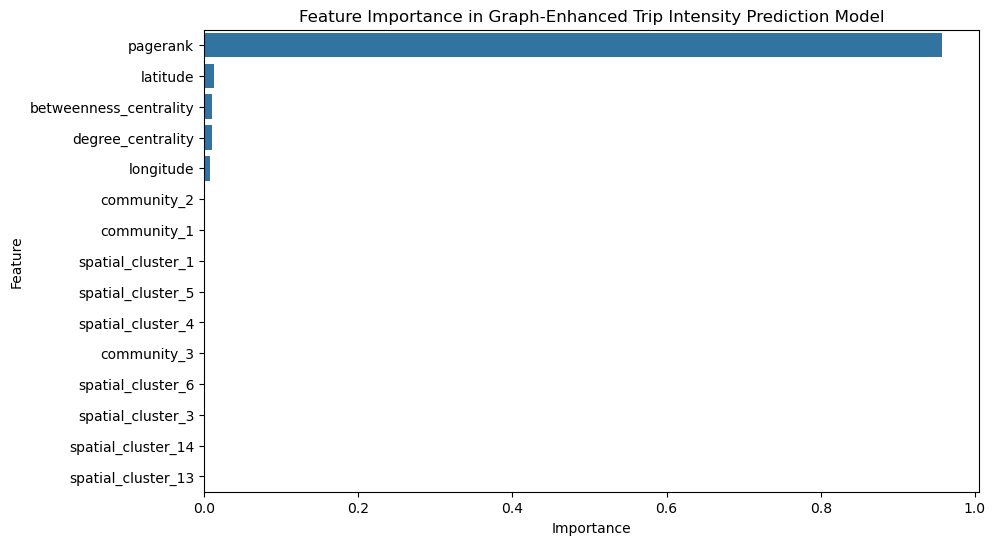

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)
plt.title("Feature Importance in Graph-Enhanced Trip Intensity Prediction Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance results show that PageRank centrality is by far the most influential predictor of station-level trip intensity.

This suggests that bike-sharing activity is strongly associated with broader mobility network structure rather than purely local spatial characteristics.

Stations connected to other highly influential stations tend to exhibit substantially higher trip volumes, highlighting the importance of network accessibility and spatial connectivity within London's bike-sharing system.

The comparatively lower importance of geographic coordinates and clustering variables further suggests that relational network structure plays a stronger role than absolute location alone in explaining station-level activity.

However, PageRank is derived from the observed mobility network itself, meaning that the model should be interpreted as a graph-enhanced explanatory workflow rather than a purely independent forecasting model.

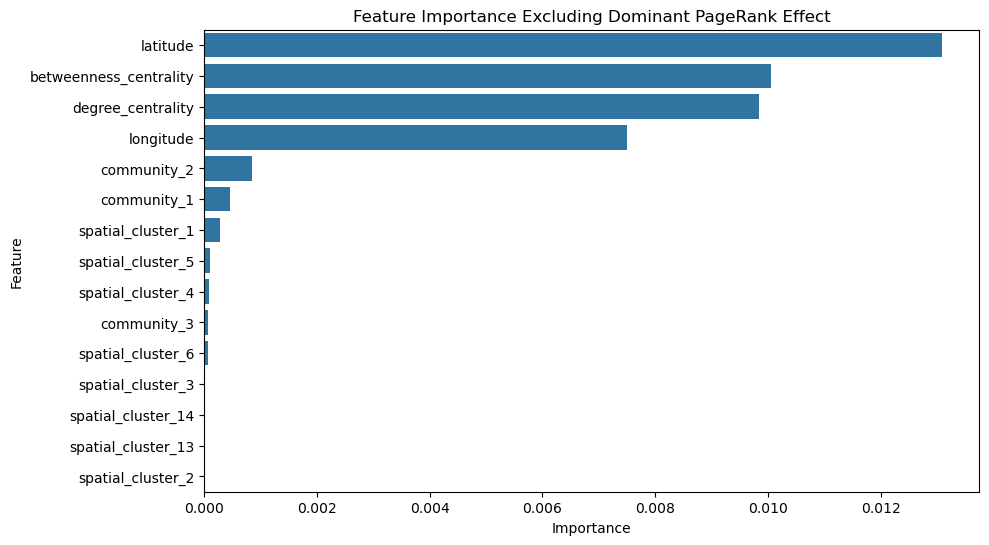

In [34]:
feature_importance_zoom = (
    feature_importance[
        feature_importance["feature"] != "pagerank"
    ]
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_zoom,
    x="importance",
    y="feature"
)

plt.title("Feature Importance Excluding Dominant PageRank Effect")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

After excluding the dominant PageRank effect, additional spatial and graph-derived variables become more visible. Latitude and longitude suggest that station activity is partly shaped by geographic location within London. Betweenness centrality and degree centrality also remain important, indicating that stations occupying structurally strategic or highly connected positions in the mobility network tend to experience higher trip intensity.

Community membership and DBSCAN spatial clusters have lower but still observable importance, suggesting that broader mobility regions and local spatial concentrations provide additional explanatory value. Overall, the results support the argument that station-level trip intensity is shaped by both spatial location and relational network structure.

However, feature importance should be interpreted cautiously because PageRank is derived from the observed mobility network and is therefore closely related to the target variable.

## 15. Discussion

 This project demonstrates that London's Santander Cycles system exhibits strong spatial structure, network concentration, and spatial heterogeneity.

 First, the network centrality analysis shows that highly influential stations are concentrated around central London and major transport interchanges. This suggests that bike-sharing is closely integrated into broader patterns of urban accessibility and multimodal transport connectivity.

 Second, community detection reveals that London's bike-sharing network is organised into spatially coherent mobility regions rather than functioning as a homogeneous city-wide system. The observed east-west separation likely reflects differences in land use, employment concentration, commuting flows, and transport infrastructure.

 Third, the spatial clustering and distance decay analyses demonstrate that bike-sharing activity is highly localised. Most journeys occur over relatively short distances and station density is strongly concentrated within highly accessible central urban areas.

 Finally, the machine learning workflow demonstrates that graph-derived features substantially improve prediction of station-level trip intensity. This highlights the importance of integrating network structure into AI-enhanced urban mobility analytics.

## 16. Policy Implications

 The findings have several implications for sustainable urban mobility planning.

 First, high-centrality stations may require priority attention for bike redistribution, maintenance, and docking capacity management.

 Second, spatial communities can help planners understand functional cycling regions and design infrastructure that supports existing movement patterns.

 Third, areas with lower station density or weaker network integration may require targeted investment to improve cycling accessibility and reduce spatial inequalities in shared mobility provision.

 Finally, the integration of graph analytics and machine learning demonstrates how urban data can support evidence-based decision-making for sustainable transport planning.

## 17. Limitations

 Several limitations should be acknowledged. First, the analysis uses TfL Santander Cycles data only and does not capture private cycling trips. Second, although the dataset covers five months in 2025, it does not represent a full annual cycle. Third, the analysis does not include weather, demographic, land-use, or employment data, all of which may influence cycling behaviour. Fourth, station coordinate matching may be affected by naming inconsistencies between journey data and the BikePoint API.

 Future work could integrate borough boundaries, census data, weather data, and land-use indicators to support more detailed spatial regression or geographically weighted regression analysis.

## 18. Conclusion

 This project developed a spatial-temporal urban analytics workflow for analysing London's Santander Cycles system. By combining journey-level data, graph modelling, spatial clustering, distance decay analysis, and machine learning, the project demonstrated how shared cycling can be understood as a complex spatial mobility network.

 The analysis identified important mobility hubs, spatially distinct cycling communities, short-distance travel patterns, and the predictive value of graph-derived features for station-level trip intensity. These findings show that advanced urban analytics can provide useful evidence for sustainable transport planning, cycling infrastructure investment, and data-driven urban policy.

# References

Anselin, L. (1995) ‘Local indicators of spatial association—LISA’, *Geographical Analysis*, 27(2), pp. 93–115.

Barabási, A.-L. (2016) *Network Science*. Cambridge: Cambridge University Press.

Batty, M. (2013) *The New Science of Cities*. Cambridge, MA: MIT Press.

Faghih-Imani, A. and Eluru, N. (2016) ‘Incorporating the impact of spatio-temporal interactions on bicycle sharing system demand: A case study of New York CitiBike system’, *Journal of Transport Geography*, 54, pp. 218–227.

Ferro, P.S., Santana, I., Lopes, S. and Cabral, J. (2014) ‘Data mining applied to big data generated by the bike-sharing service: The case of Barcelona’, *Journal of Systems and Information Technology*, 16(3), pp. 306–321.

Fishman, E. (2016) ‘Bikeshare: A review of recent literature’, *Transport Reviews*, 36(1), pp. 92–113.

Hansen, W.G. (1959) ‘How accessibility shapes land use’, *Journal of the American Institute of Planners*, 25(2), pp. 73–76.

Kitchin, R. (2014) ‘The real-time city? Big data and smart urbanism’, *GeoJournal*, 79(1), pp. 1–14.

Li, W. (2020) ‘GeoAI: Where machine learning and big data converge in GIScience’, *Journal of Spatial Information Science*, 20, pp. 71–77.

